# Code Assignment 17 — K-Means Model Comparison with CH & DB + Assumption Testing (Mall Customers)

**Format:** Instructor Guidance → Your Task (step-by-step) → We Share (reflection)

**Goal:**  Compare **two feature sets** for K-Means at the **same K**:  
- **Model 1:** 2 features → `['Annual Income (k$)', 'Spending Score (1-100)']`  
- **Model 2:** 3 features → `['Age', 'Annual Income (k$)', 'Spending Score (1-100)']`  
Evaluate with **Silhouette (↑), Calinski–Harabasz (↑), Davies–Bouldin (↓)**, **separation ratio** (↑), **cluster sizes**, and **stability (median ARI) (↑)**.



## Instructor Guidance (Pseudocode + Docs)

**Docs**  
- `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
- `KMeans`: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html  
- `silhouette_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html  
- `calinski_harabasz_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html  
- `davies_bouldin_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html  
- `adjusted_rand_score` (stability): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html

### Pseudocode Plan (Model Comparison)
  1) Load CSV → pick clean numeric columns (2D vs 3D).  
  2) **Scale** each feature set **separately** with `StandardScaler`.  
  3) Fix **K** (e.g., K=4).  
  4) Fit KMeans on each set → get labels & centers.  
  5) Compute metrics: `silhouette_score` (↑), `calinski_harabasz_score` (↑), `davies_bouldin_score` (↓).  
  6) Assumption checks: **separation ratio** (min between-centroid distance ÷ max within-cluster spread), **cluster sizes** (%), **stability via ARI** across seeds.  
  7) Compare models in a table → pick one and justify.


## Your Task — Step-by-Step
Work in pairs. Keep it minimal and clear.

### 0) Run Helper Functions and do your Imports

In [116]:
# RUN THIS CELL WITHOUT CHANGES 

def cluster_size_pct(labels):
    """Return % size of each cluster (sorted by cluster index)."""
    s = pd.Series(labels).value_counts(normalize=True).sort_index()
    return (s * 100).round(1)

def within_between_ratio(Z, labels, centers):
    """
    Heuristic separation metric:
    min distance among centroids ÷ max within-cluster spread (avg feature std per cluster).
    Higher is better (more separated vs within spread).
    """
    within = []
    for c in range(centers.shape[0]):
        pts = Z[labels == c]
        if len(pts) == 0:
            within.append(np.nan)
        else:
            within.append(pts.std(axis=0).mean())
    within = np.array(within, dtype=float)
    max_within = np.nanmax(within)

    D = cdist(centers, centers)  # centroid distance matrix
    np.fill_diagonal(D, np.nan)
    min_between = np.nanmin(D)
    return float(min_between / max_within)

def stability_ari(Z, k, seeds=(0, 1, 2, 3, 4)):
    """
    Fit KMeans across multiple seeds and compute median Adjusted Rand Index across pairs.
    Higher median ARI = more stable clustering to initialization.
    """
    label_sets = []
    for s in seeds:
        km = KMeans(n_clusters=k, n_init=10, random_state=s).fit(Z)
        label_sets.append(km.labels_)
    pairs = [(i, j) for i in range(len(label_sets)) for j in range(i+1, len(label_sets))]
    aris = [adjusted_rand_score(label_sets[i], label_sets[j]) for (i, j) in pairs]
    return float(np.median(aris))


In [117]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### 1) Load the Mall Customers CSV & Preview
Use the same dataset as last time.

In [118]:
df = pd.read_csv("../data/Mall_Customers copy.csv")

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 2) Build 2D and 3D feature sets (numeric only, minimal cleaning)

- 2D set:  Annual Income and Spending Score
- 3D set:  Age, Annual Income, Spending Score 

**Be sure to scale!**


In [119]:
scaler = StandardScaler()

twod = df[['Annual Income (k$)','Spending Score (1-100)']]

twodscale = scaler.fit_transform(twod)

threed = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

threedscale = scaler.fit_transform(threed)



### 3) Choose a single k for BOTH models (you can try 3, 4, 5, etc.)

In [129]:
# first trying with 5
K_FIXED = 5
print('Using K =', K_FIXED)


Using K = 5


### 4) Fit Model 1 (2D @ K) and compute metrics

- No train-test split needed 
- Use helper functions above to help calculate metrics!


In [130]:
sil, ch, db = [], [], []

km = KMeans(n_clusters=K_FIXED, n_init = 10, random_state=0).fit(twodscale)
labels = km.labels_
# silhouette score
sil.append(silhouette_score(twodscale,labels))
# calinski
ch.append(calinski_harabasz_score(twodscale, labels))
# davies
db.append(davies_bouldin_score(twodscale, labels))
# separation ratio
separation = within_between_ratio(twodscale,labels,km.cluster_centers_)
# cluster sizes
clustersize = cluster_size_pct(labels)
clustersizelist = pd.to_numeric(clustersize.values)
# stability score
stability = stability_ari(twodscale, K_FIXED, seeds=(0, 1, 2, 3, 4))

allinfo = {'silhouette_score': sil,
           'calinski':ch,
           'davies':db,
           'separation ratio':separation,
           'clustersize':clustersize.to_string(),
           'stability':stability}

info = pd.DataFrame(data= allinfo)

info


,silhouette_score,calinski,davies,separation ratio,clustersize,stability
0,0.5547,248.6493,0.5722,3.1426,0 40.5000\n1 19.5000\n2 17.5000\n3 11....,1.0000


### 5) Fit Model 2 (3D @ K) and compute metrics

- No train-test split needed 
- Use helper functions above to help calculate metrics!
- Use same k as Model 1

In [131]:
sil2, ch2, db2 = [], [], []

km2 = KMeans(n_clusters=K_FIXED, n_init = 10, random_state=0).fit(threedscale)
labels2 = km2.labels_
# silhouette score
sil2.append(silhouette_score(threedscale,labels2))
# calinski
ch2.append(calinski_harabasz_score(threedscale, labels2))
# davies
db2.append(davies_bouldin_score(threedscale, labels2))
# separation ratio
separation2 = within_between_ratio(threedscale,labels2,km2.cluster_centers_)
# cluster sizes
clustersize2 = cluster_size_pct(labels2)
clustersizelist2 = pd.to_numeric(clustersize2.values)
# stability score
stability2 = stability_ari(threedscale, K_FIXED, seeds=(0, 1, 2, 3, 4))

allinfo2 = {'silhouette_score': sil2,
           'calinski':ch2,
           'davies':db2,
           'separation ratio':separation2,
           'clustersize':clustersize2.to_string(),
           'stability':stability2}

info2 = pd.DataFrame(data= allinfo2)

info2

,silhouette_score,calinski,davies,separation ratio,clustersize,stability
0,0.4166,125.1009,0.8746,2.7940,0 23.5000\n1 19.5000\n2 20.0000\n3 10....,1.0000


### 6) Visualize Model 1 (2D Scatter Plot)


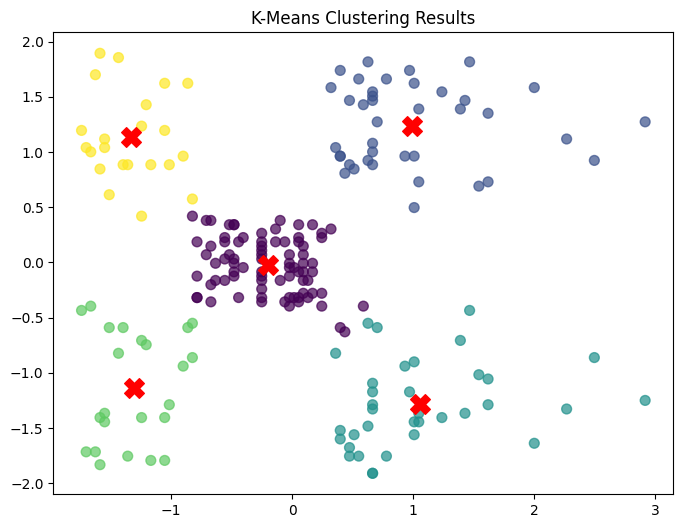

In [132]:
# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(twodscale[:, 0], twodscale[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
# Plot the centroids (the cluster centers) as red 'X's
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=200, c='red', marker='X')
plt.title('K-Means Clustering Results')
plt.show()

## We Share — Reflection (short, specific)
1) **Which model is better and why?** Reference **Sil (↑), CH (↑), DB (↓)**, **separation ratio (↑)**, **stability ARI (↑)**, and **cluster sizes**.

The better model is the 2D one with two features. Compared to the 3D model, the silhouette, CH, and separation ratio is higher, while the DB is lower. This highlights that the 2D model produces more compressed clusters with further distance from each other.

2) **Assumptions & ethics:** Did your chosen model show **non-overlapping, roughly spherical, similarly dense** clusters? If not, what risk could that pose to stakeholders (mis-targeted offers, unfair treatment)?

My model showed some subtle overlapping between the clusters, and they're also not the most dense. Some of the data points can be misrepresented or categorized into a different cluster if ran again, due to those points overlapping with other clusters.

3) **Next step:** If you had to ship this, what monitoring would you add (e.g., re-check metrics quarterly, watch for tiny cluster drift, re-scale after schema changes)?

If I had to ship this, I would re-check the metrics after providing more data, as when more data is introduced, the shape of clusters can change.

> Tip: If metrics conflict (e.g., CH prefers K=6, DB prefers K=4), prefer **parsimonious K** with **clear separation**, **stable labels**, and **business actionability**.
